CUDA available: True
Device: Tesla T4
Train images: 2533
Test images: 318
Train batches: 1266
Test batches: 159
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 181MB/s]


Model: SSDlite320-MobileNetV3
Parameters: 3792380

===== Epoch 1/30 started =====
Epoch 1 | Batch 1/1266 | Loss: 14.8395
Epoch 1 | Batch 2/1266 | Loss: 14.5583
Epoch 1 | Batch 3/1266 | Loss: 13.0822
Epoch 1 | Batch 4/1266 | Loss: 15.5398
Epoch 1 | Batch 5/1266 | Loss: 16.4664
Epoch 1 | Batch 6/1266 | Loss: 12.9981
Epoch 1 | Batch 7/1266 | Loss: 14.8649
Epoch 1 | Batch 8/1266 | Loss: 12.1086
Epoch 1 | Batch 9/1266 | Loss: 16.0630
Epoch 1 | Batch 10/1266 | Loss: 11.0045
Epoch 1 | Batch 11/1266 | Loss: 11.8464
Epoch 1 | Batch 12/1266 | Loss: 10.6533
Epoch 1 | Batch 13/1266 | Loss: 11.1849
Epoch 1 | Batch 14/1266 | Loss: 11.6009
Epoch 1 | Batch 15/1266 | Loss: 10.5885
Epoch 1 | Batch 16/1266 | Loss: 10.7554
Epoch 1 | Batch 17/1266 | Loss: 10.9600
Epoch 1 | Batch 18/1266 | Loss: 10.4576
Epoch 1 | Batch 19/1266 | Loss: 10.2854
Epoch 1 | Batch 20/1266 | Loss: 11.8649
Epoch 1 | Batch 21/1266 | Loss: 10.5749
Epoch 1 | Batch 22/1266 | Loss: 10.7123
Epoch 1 | Batch 23/1266 | Loss: 8.0984
Epoch 1 

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Model: SSDlite320-MobileNetV3
Parameters: 3792380
Training Time (seconds): 4362.388548612595
Average Inference Time (seconds): 0.019720585841052938
Total Test Inference Time (seconds): 3.135573148727417
FPS: 101.41686540754483
mAP@0.5 (%): 81.5225830078125
mAP@0.5:0.95 (%): 47.34477996826172
Precision (%): 77.22513089005236
Recall (%): 67.81609195402298
Detection Accuracy (%): 77.22513089005236


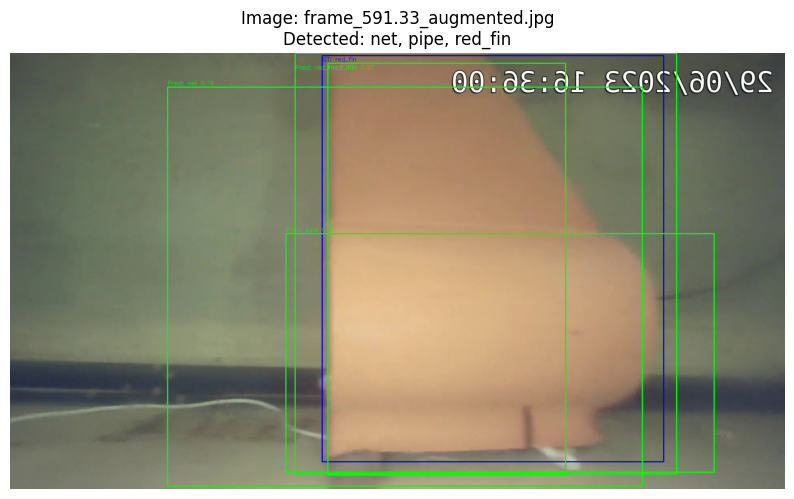

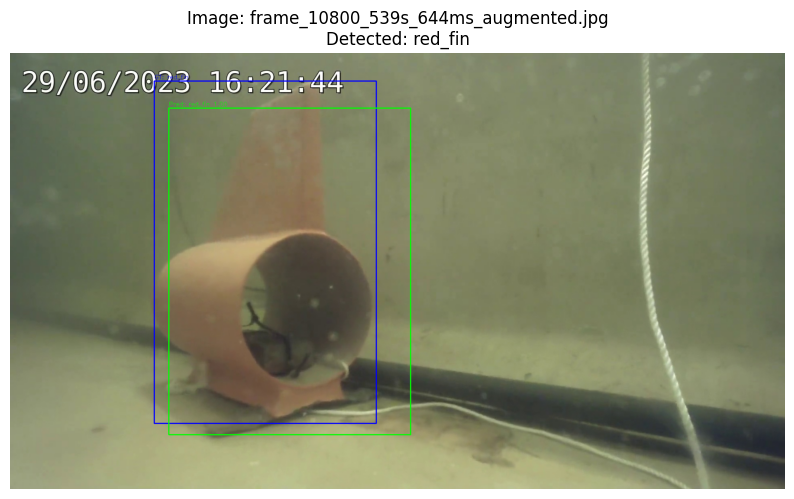

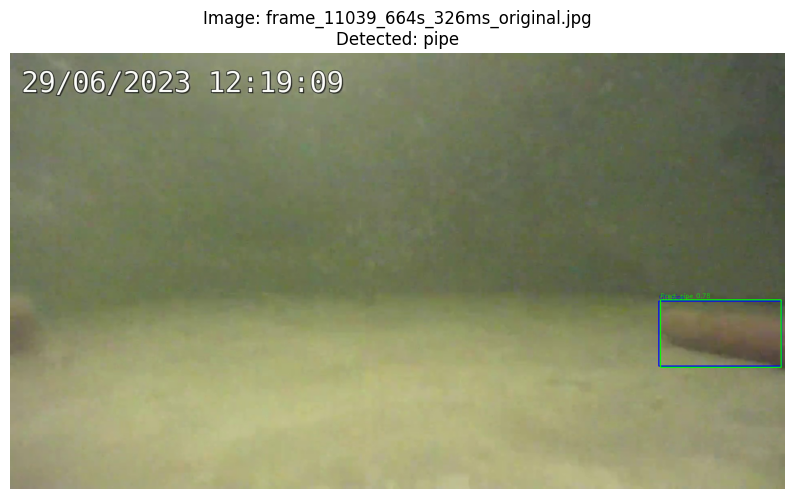

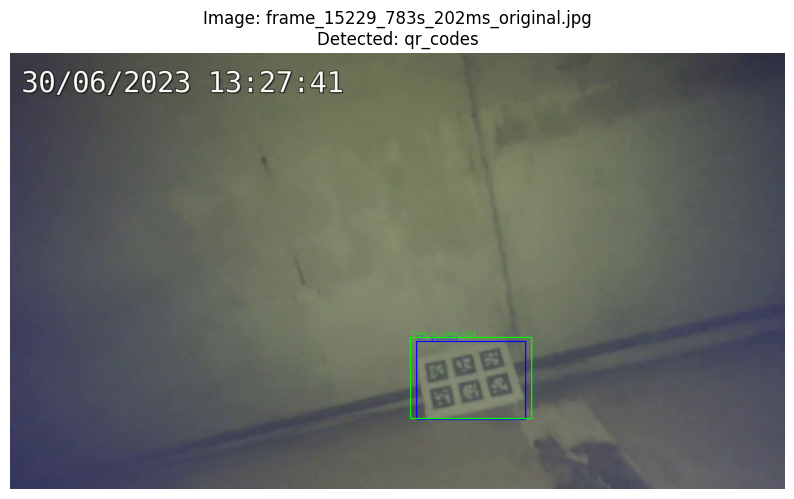

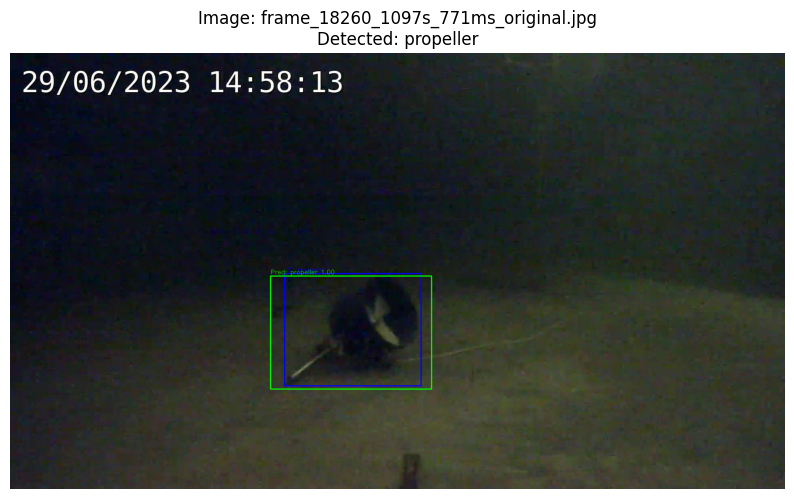


Summary saved to: /kaggle/working/ssdlite_results/summary.json
{'model': 'SSDlite320-MobileNetV3', 'parameters': 3792380, 'training_time_seconds': 4362.388548612595, 'avg_inference_time_seconds': 0.019720585841052938, 'total_test_inference_time_seconds': 3.135573148727417, 'fps': 101.41686540754483, 'map50_percent': 81.5225830078125, 'map50_95_percent': 47.34477996826172, 'precision_percent': 77.22513089005236, 'recall_percent': 67.81609195402298, 'detection_accuracy_percent': 77.22513089005236}


In [1]:
!pip install -q torchmetrics opencv-python pillow matplotlib

import os, cv2, glob, json, time, random
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models import MobileNet_V3_Large_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

DATASET_PATH = "/kaggle/input/datasets/mdanzirhossainrafath/dataset1/Dataset1"
TRAIN_IMG = f"{DATASET_PATH}/train/images"
TRAIN_LBL = f"{DATASET_PATH}/train/labels"
TEST_IMG  = f"{DATASET_PATH}/test/images"
TEST_LBL  = f"{DATASET_PATH}/test/labels"

RESULTS_DIR = "/kaggle/working/ssdlite_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASSES = ["propeller", "pipe_type2", "red_fin", "net", "qr_codes", "pipe"]
NUM_CLASSES = len(CLASSES) + 1   # +1 for background

CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
VIS_SAMPLES = 5
BATCH_SIZE_TRAIN = 2
BATCH_SIZE_TEST = 2
EPOCHS = 30

def list_images(folder):
    return sorted(
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.jpeg")) +
        glob.glob(os.path.join(folder, "*.png"))
    )

def read_yolo_labels(txt_file, W, H, class_shift=0):
    boxes, labels = [], []
    if not os.path.exists(txt_file):
        return boxes, labels

    with open(txt_file, "r") as f:
        for line in f:
            c, x, y, w, h = line.strip().split()
            c = int(float(c)) + class_shift
            x, y, w, h = map(float, [x, y, w, h])

            x1 = (x - w / 2) * W
            y1 = (y - h / 2) * H
            x2 = (x + w / 2) * W
            y2 = (y + h / 2) * H

            boxes.append([x1, y1, x2, y2])
            labels.append(c)

    return boxes, labels

def iou_xyxy(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    areaB = max(0, b[2] - b[0]) * max(0, b[3] - b[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def collate_fn(batch):
    return tuple(zip(*batch))

class YOLODetectionDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images = list_images(images_dir)
        self.labels_dir = labels_dir

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        label_path = os.path.join(
            self.labels_dir,
            os.path.splitext(os.path.basename(img_path))[0] + ".txt"
        )
        boxes, labels = read_yolo_labels(label_path, W, H, class_shift=1)

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64)
        }

        return F.to_tensor(img), target

train_dataset = YOLODetectionDataset(TRAIN_IMG, TRAIN_LBL)
test_dataset  = YOLODetectionDataset(TEST_IMG, TEST_LBL)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True   # important fix for SSDlite BatchNorm
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_TEST,
    shuffle=False,
    collate_fn=collate_fn
)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

MODEL_NAME = "SSDlite320-MobileNetV3"

model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(
    weights=None,
    weights_backbone=MobileNet_V3_Large_Weights.DEFAULT,
    num_classes=NUM_CLASSES
)
model.to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())
print("Model:", MODEL_NAME)
print("Parameters:", param_count)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

train_start = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} started =====")

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {losses.item():.4f}")

    print(f"Epoch {epoch+1} total loss: {epoch_loss:.4f}")

train_end = time.time()
training_seconds = train_end - train_start

metric = MeanAveragePrecision(iou_type="bbox")
model.eval()

TP = 0
FP = 0
FN = 0
correct = 0
total_preds = 0
times = []

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(DEVICE) for img in images]

        start = time.time()
        outputs = model(images)
        end = time.time()
        times.append(end - start)

        preds_map, gts_map = [], []

        for output, target in zip(outputs, targets):
            preds_map.append({
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": output["labels"].cpu()
            })
            gts_map.append({
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            })

            pred_boxes = output["boxes"].cpu().numpy().tolist()
            pred_scores = output["scores"].cpu().numpy().tolist()
            pred_labels = output["labels"].cpu().numpy().tolist()

            gt_boxes = target["boxes"].cpu().numpy().tolist()
            gt_labels = target["labels"].cpu().numpy().tolist()

            keep = [i for i, s in enumerate(pred_scores) if s >= CONF_THRESHOLD]
            pred_boxes = [pred_boxes[i] for i in keep]
            pred_labels = [pred_labels[i] for i in keep]

            matched_gt = set()

            for pb, pl in zip(pred_boxes, pred_labels):
                total_preds += 1
                best_iou, best_idx = 0.0, -1

                for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if j in matched_gt or pl != gl:
                        continue
                    iou = iou_xyxy(pb, gb)
                    if iou > best_iou:
                        best_iou, best_idx = iou, j

                if best_iou >= IOU_THRESHOLD and best_idx != -1:
                    TP += 1
                    correct += 1
                    matched_gt.add(best_idx)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)

        metric.update(preds_map, gts_map)

results = metric.compute()

precision = (TP / (TP + FP) * 100) if (TP + FP) > 0 else 0.0
recall = (TP / (TP + FN) * 100) if (TP + FN) > 0 else 0.0
detection_accuracy = (correct / total_preds * 100) if total_preds > 0 else 0.0
avg_inference_time = float(np.mean(times)) if times else 0.0
total_inference_time = float(np.sum(times)) if times else 0.0
fps = (len(test_dataset) / total_inference_time) if total_inference_time > 0 else 0.0

print(
    f"Model: {MODEL_NAME}\n"
    f"Parameters: {int(param_count)}\n"
    f"Training Time (seconds): {float(training_seconds)}\n"
    f"Average Inference Time (seconds): {avg_inference_time}\n"
    f"Total Test Inference Time (seconds): {total_inference_time}\n"
    f"FPS: {fps}\n"
    f"mAP@0.5 (%): {float(results['map_50'] * 100)}\n"
    f"mAP@0.5:0.95 (%): {float(results['map'] * 100)}\n"
    f"Precision (%): {float(precision)}\n"
    f"Recall (%): {float(recall)}\n"
    f"Detection Accuracy (%): {float(detection_accuracy)}"
)

sample_imgs = os.listdir(TEST_IMG)[:VIS_SAMPLES]

for img_name in sample_imgs:
    img = cv2.imread(os.path.join(TEST_IMG, img_name))
    H, W, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lbl_path = os.path.join(TEST_LBL, os.path.splitext(img_name)[0] + ".txt")
    gt_boxes, gt_labels = read_yolo_labels(lbl_path, W, H, class_shift=1)

    detected_names = []

    for b, lbl in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = map(int, b)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(
            img_rgb,
            f"GT: {CLASSES[lbl-1]}",
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 255),
            1
        )

    with torch.no_grad():
        pred = model([F.to_tensor(img_rgb).to(DEVICE)])[0]

    for b, s, lbl in zip(
        pred["boxes"].cpu().numpy(),
        pred["scores"].cpu().numpy(),
        pred["labels"].cpu().numpy()
    ):
        if s < CONF_THRESHOLD:
            continue

        x1, y1, x2, y2 = map(int, b)
        class_name = CLASSES[lbl - 1]
        detected_names.append(class_name)

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img_rgb,
            f"Pred: {class_name} {s:.2f}",
            (x1, max(40, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(
        f"Image: {img_name}\n"
        f"Detected: {', '.join(sorted(set(detected_names))) if detected_names else 'No object detected'}"
    )
    plt.axis("off")
    plt.show()

summary = {
    "model": "SSDlite320-MobileNetV3",
    "parameters": int(param_count),
    "training_time_seconds": float(training_seconds),
    "avg_inference_time_seconds": avg_inference_time,
    "total_test_inference_time_seconds": total_inference_time,
    "fps": fps,
    "map50_percent": float(results["map_50"] * 100),
    "map50_95_percent": float(results["map"] * 100),
    "precision_percent": float(precision),
    "recall_percent": float(recall),
    "detection_accuracy_percent": float(detection_accuracy)
}

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nSummary saved to:", os.path.join(RESULTS_DIR, "summary.json"))
print(summary)